This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [12]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner.tuners import Hyperband
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data')

In [14]:
files_calc = glob.glob('*.dat')
files_exp = glob.glob('*processed.gr')

Counts of clusters by their nuclearity: {'1': 0, '2': 13, '3': 12, '4': 50, '5': 10, '6': 19, '7': 8, '8': 5, '9': 6}
Sliced cluster catalogue: ['3_RAQFIA.dat', '4_EGEYOF.dat', '3_Gd3_new_cluster.dat', '4_dy4.dat', '4_MAGFOR.dat', '7_XOSZOW.dat', '6_Nd6O.dat', '4_ATODUK.dat', '4_ATODOE.dat', '2_GETPEB.dat', '3_AZUFUW.dat', '4_Nd4_tetr.dat', '2_DELHIM.dat', '7_OCOSIK.dat', '6_eu6-glaz.dat', '2_NAJKIU01.dat', '6_tb6piv.dat', '2_WABCIM.dat', '7_DOVBUN.dat', '4_IJAQOA.dat', '2_NERWOX.dat', '4_BOQXAH.dat', '2_la2(tfa)6(deta)2.dat', '6_Nd6.dat', '4_QEJWUZ.dat', '8_VIMNUC.dat', '6_SUTROQ.dat', '4_sm4_mono.dat', '5_HOPJAX01.dat', '4_Gd4_opt.dat', '7_BODGOS.dat', '3_Gd3(O)(tfa)7(Htfa)(H2O)n_opt.dat', '4_IMIGAN.dat', '4_Nd4.dat', '8_DAQJEM.dat', '4_tb4.dat', '9_BALLIL.dat', '5_LAVJAV.dat', '4_Eu4.dat', '2_Gd2(tfa)5(iPrOH)2(H2O)4_opt.dat', '4_ga18.dat', '8_UKANEA.dat', '6_CAKBAT.dat', '5_ARULIK.dat', '4_KIFDEI.dat', '6_XIRNIV.dat', '4_GIZVOA.dat', '6_wrong_cpd.dat', '3_HAYNIF.dat', '3_ADUSUO.dat'

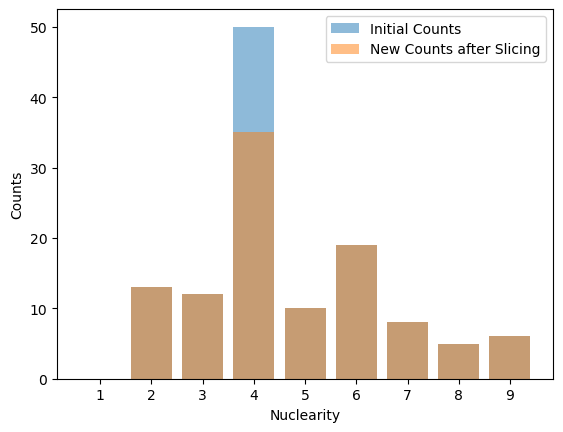

In [15]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

files_calc.extend(files_exp)
counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 100, # Specify how many filenames starting with '1' you want
    '2': 100, # Specify how many filenames starting with '2' you want
    '3': 100,  # Specify how many filenames starting with '3' you want
    '4': 35,  # Specify how many filenames starting with '3' you want
    '5': 100,  # Specify how many filenames starting with '3' you want
    '6': 100,  # Specify how many filenames starting with '3' you want
    '7': 100,  # Specify how many filenames starting with '3' you want
    '8': 100,  # Specify how many filenames starting with '3' you want
    '9': 100  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)

plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [16]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc_sliced:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')

        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

4


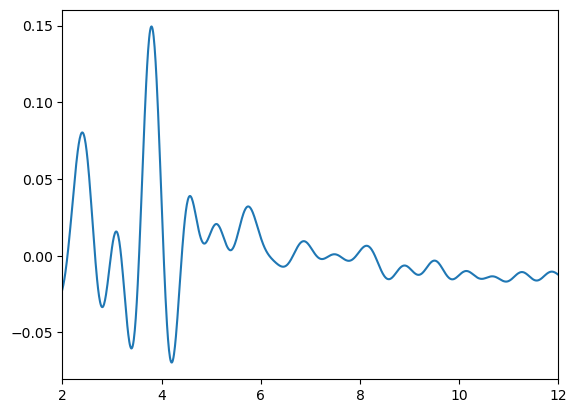

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[80,:]))/100+2, data_points[80,:])
print(labels[80])


In [7]:
def create_model():
    # Tuning of the model

    model = Sequential()
    # Add the convolutional layers
    model.add(Conv1D(filters=8, kernel_size=256, activation='relu', input_shape=(1000, 1))) # 4, 256
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2)) # 2
    model.add(Dropout(0.4)) # 0.7
    model.add(Conv1D(filters=32, kernel_size=16, activation='relu')) # 64, 128
    # model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32

    model.add(SeqSelfAttention(attention_width=32, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 32

    # Flatten the output of the convolutional layers
    model.add(Flatten())

    # Add the fully connected layers
    model.add(Dense(units=256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 
    model.add(Dropout(0.4))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 

    # Compile the model
    #optimizer = RMSprop(learning_rate=0.0001) # 0.001
    optimizer = Adam(learning_rate=0.00017)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


In [8]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1  # to keep track of which fold you're on
all_fold_results = []  # list to store performance metrics for each fold

In [9]:
for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]
    
    model = create_model()
    
    checkpoint_name = f"new_fold_{fold_num}_model.hdf5"
    checkpoint = ModelCheckpoint(checkpoint_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    
    print(f'Training fold {fold_num}...')
    model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    
    # Load the best model saved by the checkpoint and evaluate
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(checkpoint_name)
        
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)
    
    all_fold_results.append(val_acc)
    
    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))

Training fold 1...
Epoch 1/200


2023-08-14 14:08:28.347884: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


3/4 [=====================>........] - ETA: 0s - loss: 7.2694 - accuracy: 0.2708
Epoch 1: val_accuracy improved from -inf to 0.18182, saving model to new_fold_1_model.hdf5
4/4 [==============================] - 1s 128ms/step - loss: 7.2756 - accuracy: 0.2680 - val_loss: 7.2594 - val_accuracy: 0.1818
Epoch 2/200
3/4 [=====================>........] - ETA: 0s - loss: 6.7971 - accuracy: 0.3542
Epoch 2: val_accuracy improved from 0.18182 to 0.27273, saving model to new_fold_1_model.hdf5
4/4 [==============================] - 0s 67ms/step - loss: 6.8078 - accuracy: 0.3505 - val_loss: 7.0291 - val_accuracy: 0.2727
Epoch 3/200
3/4 [=====================>........] - ETA: 0s - loss: 6.4899 - accuracy: 0.4167
Epoch 3: val_accuracy improved from 0.27273 to 0.36364, saving model to new_fold_1_model.hdf5
4/4 [==============================] - 0s 73ms/step - loss: 6.4971 - accuracy: 0.4124 - val_loss: 6.8111 - val_accuracy: 0.3636
Epoch 4/200
3/4 [=====================>........] - ETA: 0s - loss: 6.

1/1 [==============================] - 0s 81ms/step
Confusion matrix [[3 0 0 0 0 0 0]
 [0 3 0 0 0 0 0]
 [0 0 4 0 0 0 0]
 [0 0 1 2 0 0 0]
 [0 0 0 0 5 0 0]
 [0 0 0 0 0 3 0]
 [0 0 0 0 0 0 1]]
Recall score: [1.         1.         1.         0.66666667 1.         1.
 1.        ]
F1 score: [1.         1.         0.88888889 0.8        1.         1.
 1.        ]
Precision score: [1.  1.  0.8 1.  1.  1.  1. ]
Confusion matrix, without normalization
[[3 0 0 0 0 0 0]
 [0 3 0 0 0 0 0]
 [0 0 4 0 0 0 0]
 [0 0 1 2 0 0 0]
 [0 0 0 0 5 0 0]
 [0 0 0 0 0 3 0]
 [0 0 0 0 0 0 1]]


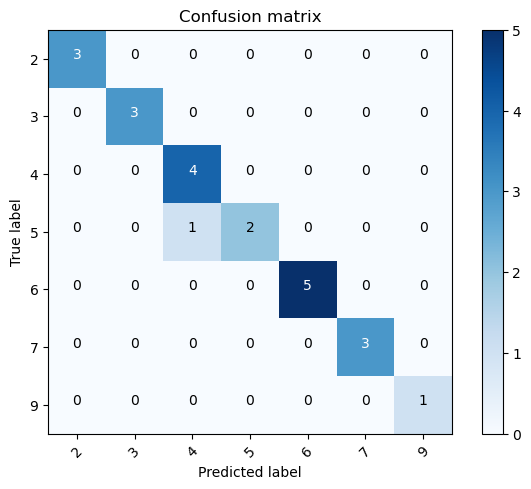

In [11]:
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/new_fold_3_model.hdf5')

load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Tuning of the model

model = Sequential()
# Add the convolutional layers
model.add(Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1000, 1))) # 32, 128
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.5)) # 0.5
model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32

model.add(SeqSelfAttention(attention_width=32, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 32

# Flatten the output of the convolutional layers
model.add(Flatten())

# Add the fully connected layers
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001))) # 128 l2 0.01
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.0001))) # 10 l2 0.01

# Compile the model
#optimizer = RMSprop(learning_rate=0.0001) # 0.001
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
# Train the model
num_epochs = 200

checkpoint = ModelCheckpoint("all_0-12.hdf5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpoint])
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

In [ ]:
print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [ ]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('all_0-12.hdf5')

In [ ]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

Let's combine the 10-fold which looks sort of okay with hyperparameter tuning to acheive better results

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [4, 8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [32, 64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [8, 16, 32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64, 128]),
                     activation='relu'))
    model.add(Conv1D(filters=hp.Choice('filters2', [8, 16, 32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64, 128]),
                     activation='relu'))                 
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.9, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [32, 64, 128, 256]), activation=hp.Choice('activation',['relu', 'softmax']), kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout3', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# K-Fold cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds)

# Track the best hyperparameters and scores
best_hps = []
best_scores = []

for train_index, val_index in kf.split(data_points):
    train_data, val_data = data_points[train_index], data_points[val_index]
    train_targets, val_targets = labels[train_index], labels[val_index]

    tuner = Hyperband(
        build_model,
        objective='val_accuracy',
        max_epochs=200,
        factor=3,
        project_name='hyperband_kfold'
    )

    # Search for the best hyperparameters for this fold
    tuner.search(train_data, train_targets, epochs=200, validation_data=(val_data, val_targets), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

    # Get the optimal hyperparameters
    best_hps.append(tuner.get_best_hyperparameters(num_trials=1)[0])
    best_scores.append(tuner.results_summary())

Better results were not acheived. Let's try the model trained on calculated Ce40 clusters

In [13]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/test_th_groups/tuned_sliced_th_calc_2-12_retrain.h5')

In [17]:
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

In [18]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

1/1 [==============================] - 0s 110ms/step
Confusion matrix [[0 0 2 1 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 1 3 0 0]
 [0 0 0 1 2 0 0]
 [0 0 0 0 4 0 1]
 [0 0 0 0 2 1 0]
 [0 0 0 0 0 1 0]]
Recall score: [0.         0.         0.         0.33333333 0.8        0.33333333
 0.        ]
F1 score: [0.         0.         0.         0.33333333 0.42105263 0.4
 0.        ]
Precision score: [0.         0.         0.         0.33333333 0.28571429 0.5
 0.        ]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix, without normalization
[[0 0 2 1 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 1 3 0 0]
 [0 0 0 1 2 0 0]
 [0 0 0 0 4 0 1]
 [0 0 0 0 2 1 0]
 [0 0 0 0 0 1 0]]


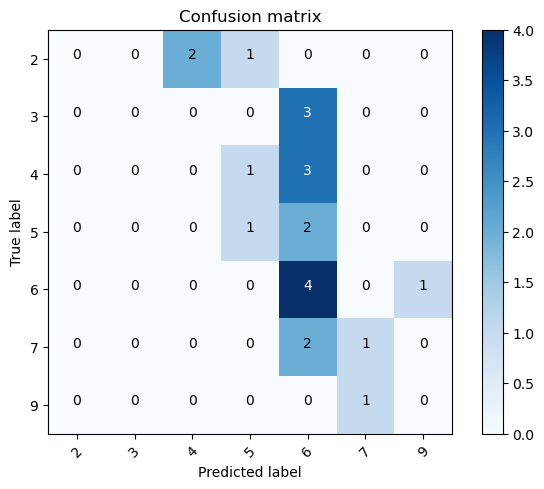

In [19]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()